### Agentic RAG

📚 What is Agentic RAG?
Agentic RAG stands for Agentic Retrieval Augmented Generation - an advanced version of RAG where instead of a static, one-shot LLM response, the system uses an agent that:

- reason
- plans
- retrieves
- use tools
- and even retries or reflects to generate better, more grounded answers

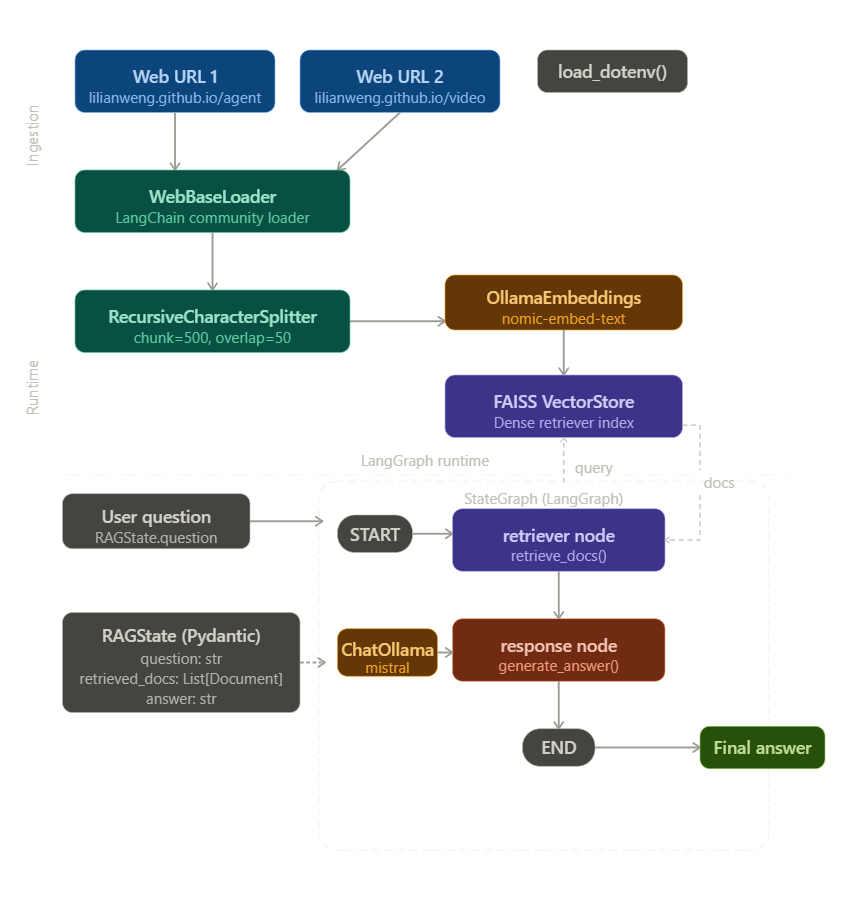

In [11]:
# ------------------------------------------------------------
# 1. Document Preprocessing
# ------------------------------------------------------------

from dotenv import load_dotenv
from langchain_community.document_loaders import WebBaseLoader

load_dotenv()

urls = [
    'https://lilianweng.github.io/posts/2023-06-23-agent/',
    'https://lilianweng.github.io/posts/2024-04-12-diffusion-video/'
]

loaders = [WebBaseLoader(url) for url in urls]
docs = []
for loader in loaders:
    docs.extend(loader.load())

In [12]:
# ------------------------------------------------------------
# 2. Splitting text, Embedding and Vector store
# ------------------------------------------------------------

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_ollama.embeddings import OllamaEmbeddings
from langchain_community.vectorstores import FAISS

# Splitting Text
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
split_docs = splitter.split_documents(docs)

# Embedding
embedding = OllamaEmbeddings(model='nomic-embed-text')

# Vector Store
vectorstore = FAISS.from_documents(split_docs, embedding)
retriever = vectorstore.as_retriever()

In [ ]:
# ------------------------------------------------------------
# 3. Define RAG State
# ------------------------------------------------------------

from typing import List, Annotated
from pydantic import BaseModel
from langchain_classic.schema import Document

class RAGState(BaseModel):
    question: str
    retrieved_docs: List[Document] = []
    answer: str = ""

In [14]:
# ------------------------------------------------------------
# 4. LangGraph Nodes
# ------------------------------------------------------------

from langchain_ollama import ChatOllama

llm = ChatOllama(model='mistral', temperature=0)

def retrieve_docs(state: RAGState) -> RAGState:
    docs = retriever.invoke(state.question)
    return RAGState(question=state.question, retrieved_docs=docs)

def generate_answer(state: RAGState) -> RAGState:
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"""Answer the question based on the content.
        Context:{context}
        
        Question:{state.question}
        """
    response = llm.invoke(prompt).content
    return RAGState(question=state.question, retrieved_docs=state.retrieved_docs, answer=response)

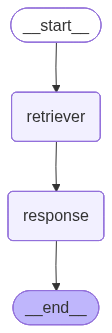

In [15]:
# ------------------------------------------------------------
# 5. Build LangGraph
# ------------------------------------------------------------

from langgraph.graph import StateGraph, START, END

builder = StateGraph(RAGState)

# Node
builder.add_node('retriever', retrieve_docs)
builder.add_node('response', generate_answer)

# Edge
builder.set_entry_point('retriever')
builder.add_edge('retriever', 'response')
builder.add_edge('response', END)

graph = builder.compile()
graph

In [17]:
# ------------------------------------------------------------
# 6. Run the Agentic RAG
# ------------------------------------------------------------

if __name__ == '__main__':
    user_question = 'What are the memories there?'
    initial_state = RAGState(question=user_question)
    final_state = graph.invoke(initial_state)
    
    final_output = {
        "question": final_state["question"],
        "answer": final_state["answer"]
    }
    
    print('\n✅ Final Answer:\n', final_output)


✅ Final Answer:
 {'question': 'What are the memories there?', 'answer': ' The memories mentioned in the context include:\n\n1. Sensory Memory: This is the earliest stage of memory, which retains impressions of sensory information (visual, auditory, etc.) after the original stimuli have ended. It typically lasts for up to a few seconds and has subcategories like iconic memory (visual), echoic memory (auditory), and haptic memory (touch).\n\n2. Explicit / Declarative Memory: This is memory of facts and events, which can be consciously recalled, including episodic memory (events and experiences) and semantic memory (facts and concepts).\n\n3. Implicit / Procedural Memory: This type of memory is unconscious and involves skills and routines that are performed automatically, like riding a bike or typing on a keyboard.\n\n4. Short-Term Memory (STM) or Working Memory: It stores information that we are currently aware of and needed to carry out complex cognitive tasks such as learning and reas